In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import utils_data_clean
import missingno as msno
import mlflow
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer,KNNImputer,MissingIndicator
from sklearn.preprocessing import OneHotEncoder,StandardScaler,LabelEncoder,MinMaxScaler,PowerTransformer,OrdinalEncoder
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,r2_score
from sklearn.feature_selection import RFECV
import warnings
warnings.filterwarnings("ignore")

In [2]:
import dagshub
dagshub.init(repo_owner='Iamkartikey44', repo_name='Food_Delivery_Time_Prediction', mlflow=True)

Accessing as Iamkartikey44

Initialized MLflow to track repo "Iamkartikey44/Food_Delivery_Time_Prediction"

Repository Iamkartikey44/Food_Delivery_Time_Prediction initialized!

In [3]:
#Set the tracking server
mlflow.set_tracking_uri("https://dagshub.com/Iamkartikey44/Food_Delivery_Time_Prediction.mlflow")

In [4]:
#Mlflow Experiment
mlflow.set_experiment("Exp1 - Keep Vs Drop Missing Values")

<Experiment: artifact_location='mlflow-artifacts:/2929366b1b6d4330a5f007a51503b55a', creation_time=1772474885553, experiment_id='0', last_update_time=1772474885553, lifecycle_stage='active', name='Exp1 - Keep Vs Drop Missing Values', tags={'mlflow.experimentKind': 'custom_model_development'}>

In [5]:

from sklearn import set_config

set_config(transform_output="pandas")

In [6]:
#Load the data
df = pd.read_csv('swiggy.csv')

In [7]:
#Clean Data
utils_data_clean.perform_data_cleaning(df)

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken(min),is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
0,37.0,4.9,sunny,high,2,snack,motorcycle,0.0,no,urban,(min) 24,1,15.0,morning,3.025149,short
1,34.0,4.5,stormy,jam,2,snack,scooter,1.0,no,metropolitian,(min) 33,0,5.0,evening,20.183530,very_long
2,23.0,4.4,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,(min) 26,1,15.0,morning,1.552758,short
3,38.0,4.7,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,(min) 21,0,10.0,evening,7.790401,medium
4,32.0,4.6,cloudy,high,1,snack,scooter,1.0,no,metropolitian,(min) 30,1,15.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45587,35.0,4.2,windy,jam,2,drinks,motorcycle,1.0,no,metropolitian,(min) 33,0,10.0,night,16.600272,very_long
45588,30.0,4.8,windy,high,1,meal,motorcycle,0.0,no,metropolitian,(min) 32,0,10.0,morning,1.489846,short
45590,30.0,4.9,cloudy,low,1,drinks,scooter,0.0,no,metropolitian,(min) 16,0,15.0,night,4.657195,short
45591,20.0,4.7,cloudy,high,0,snack,motorcycle,1.0,no,metropolitian,(min) 26,0,5.0,afternoon,6.232393,medium


In [8]:
# load the cleaned data
df = pd.read_csv('swiggy_cleaned.csv')     

In [9]:
df.head()

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,24,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,33,BANG,25,3,friday,0,5.0,19.0,evening,20.183530
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,26,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,21,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,30,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138


In [10]:
def create_distance_type(data: pd.DataFrame):
    return(
        data
        .assign(
                distance_type = pd.cut(data["distance"],bins=[0,5,10,15,25],
                                        right=False,labels=["short","medium","long","very_long"])
    ))


In [11]:
df['distance_type'] = pd.cut(df["distance"],bins=[0,5,10,15,25],
                                        right=False,labels=["short","medium","long","very_long"])

In [12]:
df.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance', 'distance_type'],
      dtype='object')

In [13]:
# drop columns not required for model input
columns_to_drop =  ['rider_id',
                    'restaurant_latitude',
                    'restaurant_longitude',
                    'delivery_latitude',
                    'delivery_longitude',
                    'order_date',
                    "order_time_hour",
                    "order_day",
                    "city_name",
                    "order_day_of_week",
                    "order_month"]

df.drop(columns=columns_to_drop, inplace=True)

In [14]:
df.sample(10)

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
11441,23.0,4.7,stormy,low,1,meal,motorcycle,1.0,no,urban,16,1,10.0,night,13.989250,long
5628,28.0,4.9,cloudy,low,1,meal,motorcycle,0.0,no,metropolitian,26,0,5.0,night,16.600954,very_long
28610,32.0,4.6,fog,jam,0,buffet,motorcycle,0.0,no,metropolitian,40,0,15.0,night,13.829132,long
44501,30.0,4.8,sandstorms,jam,0,drinks,motorcycle,1.0,no,metropolitian,40,0,15.0,night,17.078029,very_long
12965,21.0,4.7,windy,low,1,snack,motorcycle,0.0,no,urban,17,0,15.0,night,9.314031,medium
20545,34.0,4.6,stormy,jam,2,buffet,motorcycle,1.0,no,metropolitian,27,1,5.0,night,11.923473,long
3023,25.0,4.7,sandstorms,jam,0,snack,motorcycle,1.0,no,metropolitian,32,1,5.0,night,10.906379,long
42833,38.0,4.6,fog,low,2,buffet,scooter,1.0,no,metropolitian,18,1,5.0,morning,1.512524,short
18736,29.0,4.8,sandstorms,high,0,buffet,motorcycle,1.0,no,metropolitian,23,0,10.0,morning,1.520301,short
39166,NaN,NaN,NaN,NaN,3,drinks,motorcycle,1.0,no,metropolitian,19,0,NaN,after_midnight,2.979500,short


In [15]:
#Check for missing values
df.isna().sum()

age                    1854
ratings                1908
weather                 525
traffic                 510
vehicle_condition         0
type_of_order             0
type_of_vehicle           0
multiple_deliveries     993
festival                228
city_type              1198
time_taken                0
is_weekend                0
pickup_time_minutes    1640
order_time_of_day         0
distance               3630
distance_type          3630
dtype: int64

In [16]:
#Check for duplicates
df.duplicated().sum()

np.int64(0)

<Axes: >

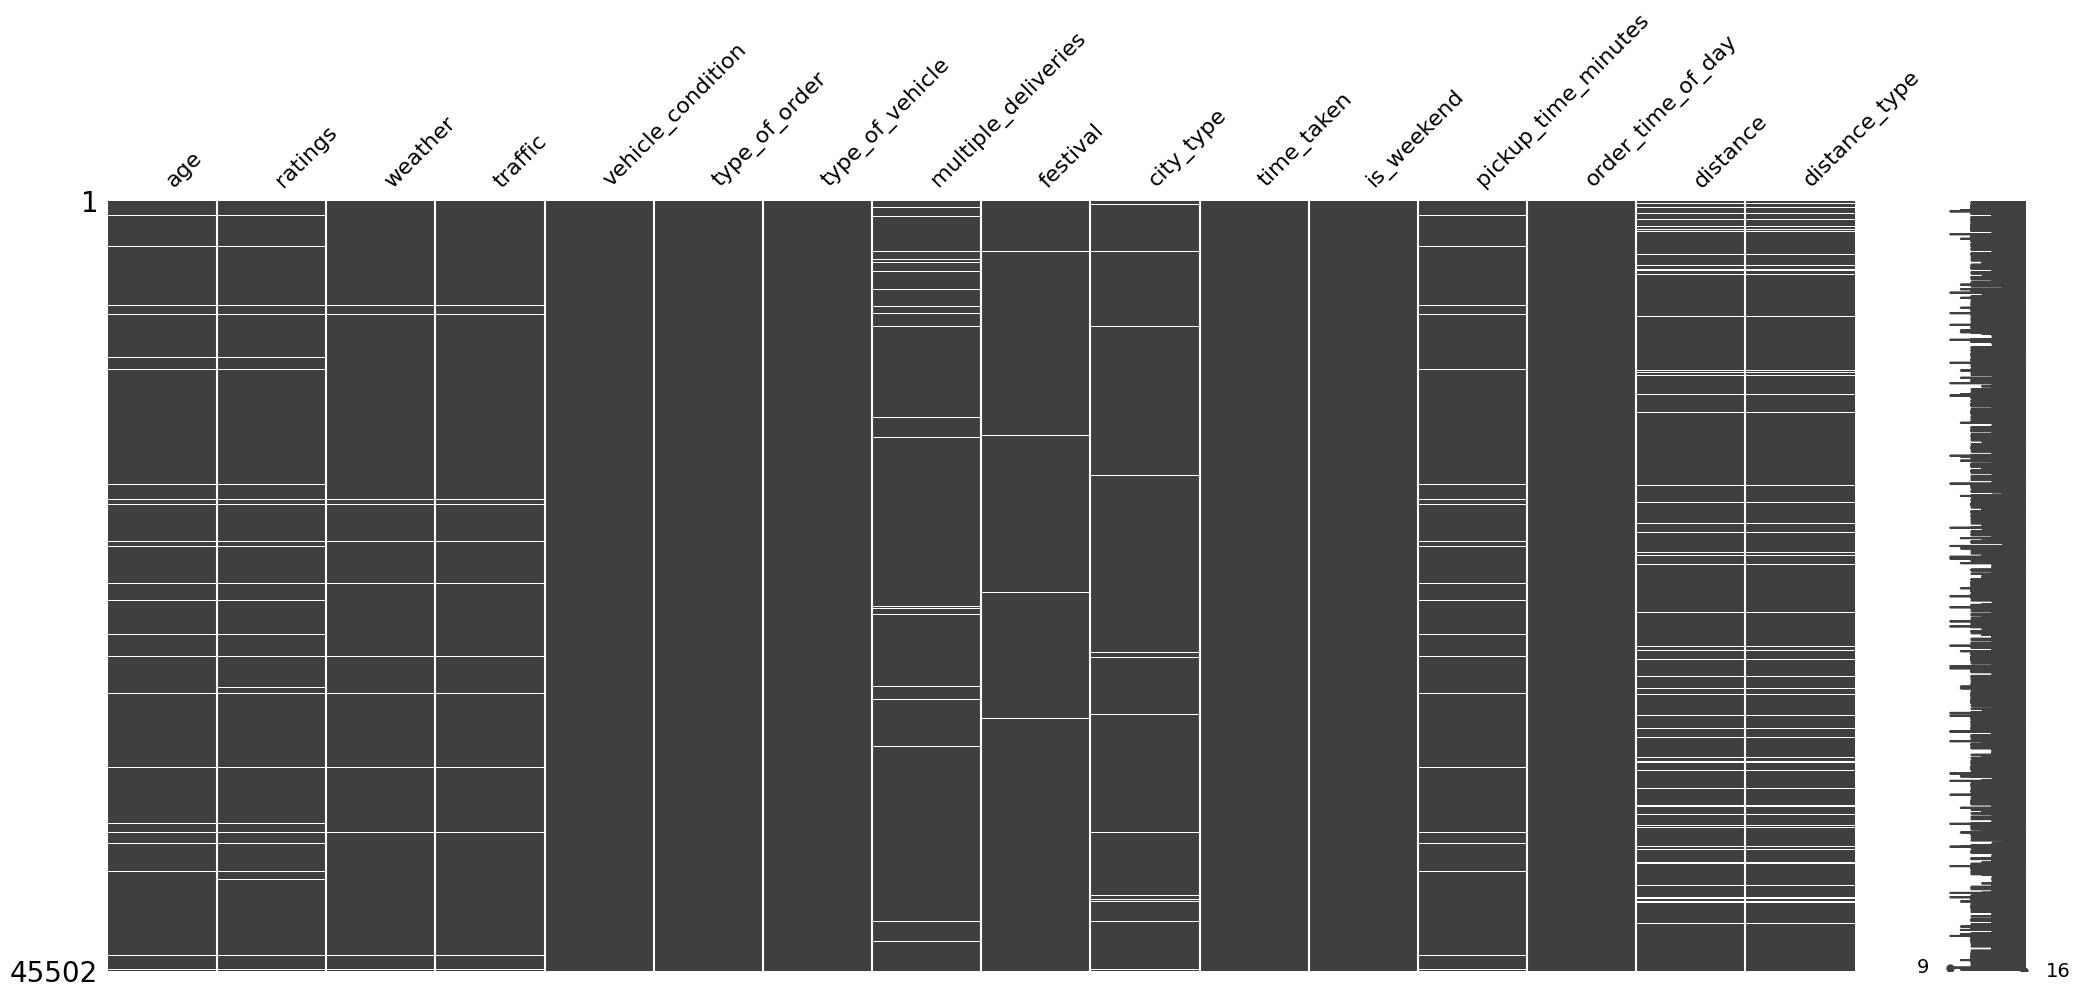

In [17]:
msno.matrix(df)

In [18]:
# columns that have missing values
missing_cols = df.isna().any(axis=0).loc[lambda x: x].index
missing_cols

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'pickup_time_minutes', 'distance',
       'distance_type'],
      dtype='object')

## Drop Missing Values

In [19]:
temp_df = df.copy().dropna()

In [20]:
#Split X and y
X = temp_df.drop(columns='time_taken')
y = temp_df['time_taken']

In [21]:
X

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
0,37.0,4.9,sunny,high,2,snack,motorcycle,0.0,no,urban,1,15.0,morning,3.025149,short
1,34.0,4.5,stormy,jam,2,snack,scooter,1.0,no,metropolitian,0,5.0,evening,20.183530,very_long
2,23.0,4.4,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,1,15.0,morning,1.552758,short
3,38.0,4.7,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,0,10.0,evening,7.790401,medium
4,32.0,4.6,cloudy,high,1,snack,scooter,1.0,no,metropolitian,1,15.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45496,35.0,4.2,windy,jam,2,drinks,motorcycle,1.0,no,metropolitian,0,10.0,night,16.600272,very_long
45497,30.0,4.8,windy,high,1,meal,motorcycle,0.0,no,metropolitian,0,10.0,morning,1.489846,short
45499,30.0,4.9,cloudy,low,1,drinks,scooter,0.0,no,metropolitian,0,15.0,night,4.657195,short
45500,20.0,4.7,cloudy,high,0,snack,motorcycle,1.0,no,metropolitian,0,5.0,afternoon,6.232393,medium


In [22]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [23]:
print("The size of train data is",X_train.shape)
print("The shape of test data is",X_test.shape)

The size of train data is (30451, 15)
The shape of test data is (7613, 15)


In [24]:
# missing data in training data
X_train.isna().sum()

age                    0
ratings                0
weather                0
traffic                0
vehicle_condition      0
type_of_order          0
type_of_vehicle        0
multiple_deliveries    0
festival               0
city_type              0
is_weekend             0
pickup_time_minutes    0
order_time_of_day      0
distance               0
distance_type          0
dtype: int64

In [25]:
X_train.columns

Index(['age', 'ratings', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'is_weekend', 'pickup_time_minutes', 'order_time_of_day',
       'distance', 'distance_type'],
      dtype='object')

In [26]:
#DO Basic Preprocessing
num_cols = ['age','ratings','pickup_time_minutes','distance']
nominal_cat_cols = ['weather','type_of_order','type_of_vehicle','festival','city_type','is_weekend','order_time_of_day']
ordinal_cat_cols = ['traffic','distance_type']

In [27]:
len(num_cols + nominal_cat_cols + ordinal_cat_cols)

13

In [28]:
for col in ordinal_cat_cols:
    print(col,X_train[col].unique())

traffic ['jam' 'low' 'medium' 'high']
distance_type ['short', 'very_long', 'long', 'medium']
Categories (4, object): ['short' < 'medium' < 'long' < 'very_long']


In [29]:
# generate order for ordinal encoding
traffic_order = ["low","medium","high","jam"]
distance_type_order = ["short","medium","long","very_long"]

In [30]:
#Build a preprocessor
preprocessor = ColumnTransformer(transformers=[
    ("scale",MinMaxScaler(),num_cols),
    ("nominal_encode",OneHotEncoder(drop='first',handle_unknown='ignore',sparse_output=False),nominal_cat_cols),
    ("ordinal_encode",OrdinalEncoder(categories=[traffic_order,distance_type_order]),ordinal_cat_cols)
],remainder='passthrough',n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)

In [31]:
preprocessor.set_output(transform="pandas")

,transformers,"[('scale', ...), ('nominal_encode', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,False
,feature_range,"(0, ...)"
,copy,True
,clip,False


In [32]:
##Transform the data
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

C:\Users\karti\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\compose\_column_transformer.py:975: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


In [33]:
X_test_trans.sample(5)

,age,ratings,pickup_time_minutes,distance,weather_fog,weather_sandstorms,weather_stormy,weather_sunny,weather_windy,type_of_order_drinks,...,city_type_urban,is_weekend_1,order_time_of_day_afternoon,order_time_of_day_evening,order_time_of_day_morning,order_time_of_day_night,traffic,distance_type,vehicle_condition,multiple_deliveries
622,0.736842,0.80,0.0,0.163982,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,3.0,0.0,2,0.0
44199,0.368421,0.88,0.0,0.552615,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,3.0,2.0,1,0.0
29535,0.315789,0.88,0.5,0.553303,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,3.0,2.0,0,1.0
13713,0.421053,0.92,0.5,0.322832,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0,1.0
42741,0.684211,0.88,0.0,0.084098,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2,0.0


In [34]:
#Transform target column

pt = PowerTransformer()

y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt = pt.transform(y_test.values.reshape(-1,1))

In [35]:
pt.lambdas_

array([0.31530635])

In [36]:
y_train_pt.values.ravel()

array([-1.05872751,  0.05134386,  1.27171334, ..., -0.91877474,
       -0.91877474,  1.1037409 ])

In [37]:
#Train the model
rf = RandomForestRegressor()
rf.fit(X_train_trans,y_train_pt.values.ravel())

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
# get the predictions
y_pred_train = rf.predict(X_train_trans)
y_pred_test = rf.predict(X_test_trans)

In [39]:
# get the actual predictions values
y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

In [40]:
print(f"The train error is {mean_absolute_error(y_train,y_pred_train_org):.2f} minutes")
print(f"The test error is {mean_absolute_error(y_test,y_pred_test_org):.2f} minutes")

The train error is 1.15 minutes
The test error is 3.14 minutes


In [41]:
print(f"The train r2 score is {r2_score(y_train,y_pred_train_org):.2f}")
print(f"The test r2 score is {r2_score(y_test,y_pred_test_org):.2f}")

The train r2 score is 0.98
The test r2 score is 0.82


## 📊 Model Performance Metrics Explained (Simple Words)

### 🔹 1️⃣ Mean Absolute Error (MAE)

- <span style="color:#60a5fa;">🟢 Train MAE: <b>1.15 minutes</b></span>  
  → On training data, the model’s predictions are off by about **1.15 minutes on average**.

- <span style="color:#facc15;">🟡 Test MAE: <b>3.14 minutes</b></span>  
  → On unseen test data, predictions are off by about **3.14 minutes on average**.

📌 **Simple Meaning:**  
If the actual delivery time is 30 minutes, the model might predict around 27–33 minutes on average.

---

### 🔹 2️⃣ R² Score (R-Squared)

- <span style="color:#34d399;">🟢 Train R²: <b>0.98</b></span>  
  → The model explains **98% of the variation** in delivery time on training data.

- <span style="color:#60a5fa;">🔵 Test R²: <b>0.82</b></span>  
  → The model explains **82% of the variation** on new unseen data.

📌 **Simple Meaning:**  
R² tells us how well the model understands the pattern in the data.  
Closer to **1** = Better fit.

---

## 🧠 What This Means Overall

- The model performs **very well on training data**.
- Performance drops slightly on test data (which is normal).
- Test R² of **0.82** is strong, meaning the model generalizes well.
- Test MAE of **~3 minutes** is practically reasonable for delivery prediction.

---

## ⚠ Important Observation

Since Train R² (0.98) is much higher than Test R² (0.82),  
👉 There may be **slight overfitting**, but not severe.

---

## 🎯 One-Line Summary

> The model predicts delivery time with an average error of about 3 minutes on unseen data and explains 82% of delivery time variation.

In [42]:
#Calculate the cross val score
scores = cross_val_score(rf,X_train_trans,y_train_pt.values.ravel(),cv=5,scoring='r2',n_jobs=-1)
scores

array([0.81406883, 0.80462141, 0.81303439, 0.80691312, 0.81122045])

In [43]:
scores.mean()

np.float64(0.8099716419835022)

<Axes: >

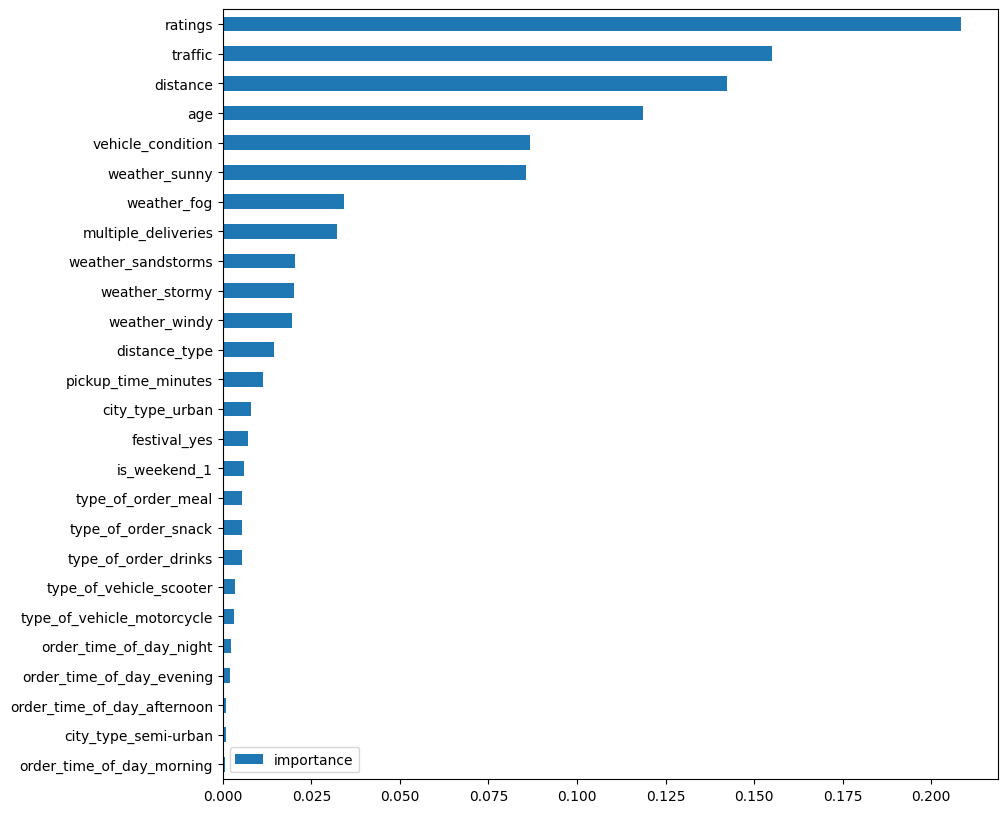

In [44]:
#Feature Importance
pd.DataFrame(rf.feature_importances_,index=X_train_trans.columns,columns=['importance']).sort_values(by='importance').plot(kind='barh',figsize=(10,10))

In [45]:
# log experiment using MLFLOW
with mlflow.start_run(run_name="Drop Missing Values"):
    mlflow.log_param("experiment_type","Drop Missing Values")
    mlflow.log_params(rf.get_params())

    #Log Metrics
    mlflow.log_metric("training_error",mean_absolute_error(y_train,y_pred_train_org))
    mlflow.log_metric("test_error",mean_absolute_error(y_test,y_pred_test_org))
    mlflow.log_metric("training_r2",r2_score(y_train,y_pred_train_org))
    mlflow.log_metric("test_r2",r2_score(y_test,y_pred_test_org))
    mlflow.log_metric("cross_val",scores.mean())

2026/03/04 16:14:57 INFO mlflow.tracking._tracking_service.client: 🏃 View run Drop Missing Values at: https://dagshub.com/Iamkartikey44/Food_Delivery_Time_Prediction.mlflow/#/experiments/0/runs/cf47bdac4bfe4ec48d3f443cea331163.
2026/03/04 16:14:57 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/Iamkartikey44/Food_Delivery_Time_Prediction.mlflow/#/experiments/0.


In [46]:
#feature selection using rfecv
rfecv = RFECV(estimator=rf,step=10,cv=5,scoring='r2',n_jobs=-1,verbose=2)

In [47]:
# select features
rfecv.fit(X_train_trans,y_train_pt.values.ravel())

,estimator,RandomForestRegressor()
,step,10
,min_features_to_select,1
,cv,5
,scoring,'r2'
,verbose,2
,n_jobs,-1
,importance_getter,'auto'
,n_estimators,100
,criterion,'squared_error'
,max_depth,None


In [48]:
# list of selected features
rfecv.get_feature_names_out()

array(['age', 'ratings', 'pickup_time_minutes', 'distance', 'weather_fog',
       'weather_sandstorms', 'weather_stormy', 'weather_sunny',
       'weather_windy', 'type_of_order_drinks', 'type_of_order_meal',
       'type_of_order_snack', 'type_of_vehicle_motorcycle',
       'type_of_vehicle_scooter', 'festival_yes', 'city_type_semi-urban',
       'city_type_urban', 'is_weekend_1', 'order_time_of_day_afternoon',
       'order_time_of_day_evening', 'order_time_of_day_morning',
       'order_time_of_day_night', 'traffic', 'distance_type',
       'vehicle_condition', 'multiple_deliveries'], dtype=object)

In [49]:
rf = RandomForestRegressor()
rf.fit(rfecv.transform(X_train_trans),y_train_pt.values.ravel())

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [50]:
# get the predictions
y_pred_train = rf.predict(rfecv.transform(X_train_trans))
y_pred_test = rf.predict(rfecv.transform(X_test_trans))

In [51]:
# get the actual predictions values
y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

In [52]:
print(f"The train error is {mean_absolute_error(y_train,y_pred_train_org):.2f} minutes")
print(f"The test error is {mean_absolute_error(y_test,y_pred_test_org):.2f} minutes")

The train error is 1.14 minutes
The test error is 3.13 minutes


In [53]:
print(f"The train r2 score is {r2_score(y_train,y_pred_train_org):.2f}")
print(f"The test r2 score is {r2_score(y_test,y_pred_test_org):.2f}")

The train r2 score is 0.98
The test r2 score is 0.83


In [54]:
scores = cross_val_score(rf,rfecv.transform(X_train_trans),y_train_pt.values.ravel(),cv=5,scoring="r2",n_jobs=-1)
scores

array([0.81438013, 0.8061815 , 0.81253137, 0.8083021 , 0.8098126 ])

In [55]:
scores.mean()

np.float64(0.8102415387043754)

In [56]:
rf.feature_importances_

array([0.11862731, 0.20882499, 0.01132994, 0.1435823 , 0.03405889,
       0.02036904, 0.02016495, 0.08493377, 0.02039629, 0.00527661,
       0.00563742, 0.00528528, 0.00311752, 0.00343781, 0.00708146,
       0.00089624, 0.00809195, 0.00587601, 0.00105552, 0.00206579,
       0.00060736, 0.00230911, 0.15348242, 0.01166925, 0.08614156,
       0.03568119])

<Axes: >

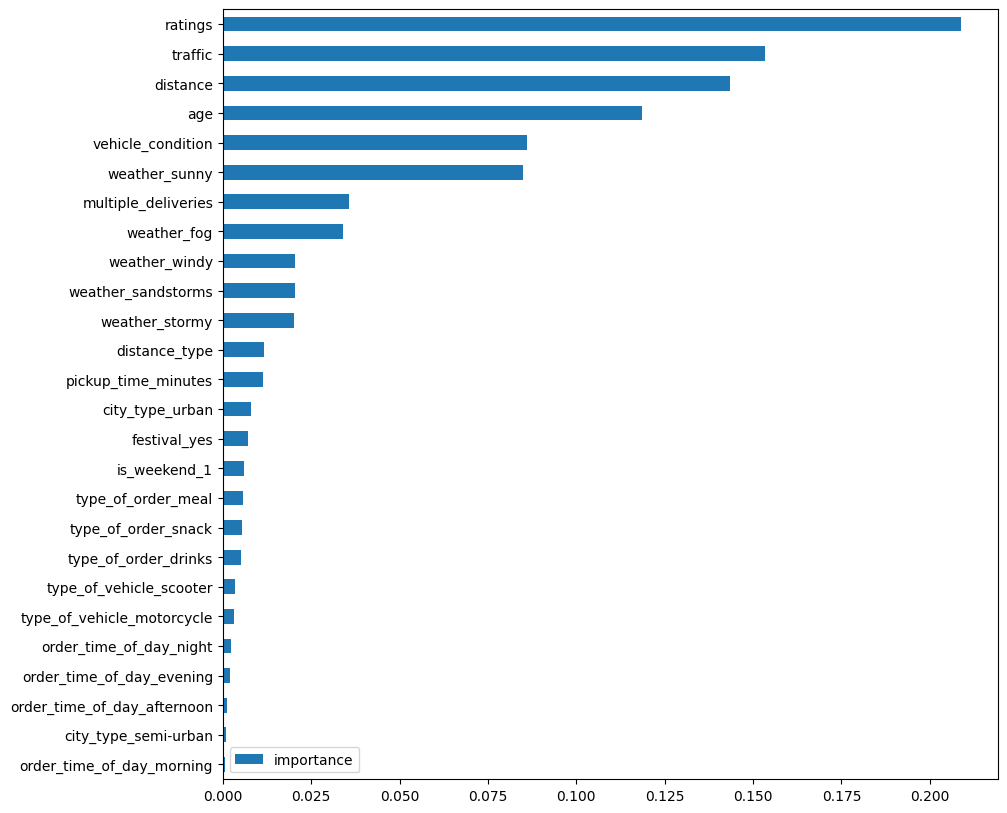

In [57]:
#Feature Importance
pd.DataFrame(rf.feature_importances_,index=rfecv.transform(X_train_trans).columns,columns=['importance']).sort_values(by='importance').plot(kind='barh',figsize=(10,10))

## Imputing Missing Values

In [58]:
temp_df = df.copy()

In [59]:
#Split into X and y
X = temp_df.drop(columns='time_taken')
y = temp_df['time_taken']

In [60]:
##Train Test Split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [61]:
print("The size of train data is",X_train.shape)
print("The shape of test data is",X_test.shape)

The size of train data is (36401, 15)
The shape of test data is (9101, 15)


In [62]:
#Missing values in train data
X_train.isna().sum()

age                    1470
ratings                1510
weather                 421
traffic                 407
vehicle_condition         0
type_of_order             0
type_of_vehicle           0
multiple_deliveries     795
festival                188
city_type               968
is_weekend                0
pickup_time_minutes    1298
order_time_of_day         0
distance               2931
distance_type          2931
dtype: int64

In [63]:
#Transform target column
pt = PowerTransformer()

y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt = pt.transform(y_test.values.reshape(-1,1))

In [64]:
missing_cols

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'pickup_time_minutes', 'distance',
       'distance_type'],
      dtype='object')

In [66]:
X_train.isna().any(axis=1).mean().round(2) * 100

np.float64(16.0)

## Imputation Pipelin

In [67]:
nominal_cat_cols

['weather',
 'type_of_order',
 'type_of_vehicle',
 'festival',
 'city_type',
 'is_weekend',
 'order_time_of_day']

In [68]:
X_train.isna().sum()

age                    1470
ratings                1510
weather                 421
traffic                 407
vehicle_condition         0
type_of_order             0
type_of_vehicle           0
multiple_deliveries     795
festival                188
city_type               968
is_weekend                0
pickup_time_minutes    1298
order_time_of_day         0
distance               2931
distance_type          2931
dtype: int64

In [69]:
#Features to fill values with mode
features_to_fill_mode = ['multiple_deliveries','festival','city_type']
features_to_fill_missing = [col for col in nominal_cat_cols if col not in features_to_fill_mode]
features_to_fill_missing

['weather',
 'type_of_order',
 'type_of_vehicle',
 'is_weekend',
 'order_time_of_day']

In [71]:
# simple imputer to fill categorical vars with mode
simple_imputer = ColumnTransformer(transformers=[
    ("mode_imputer",SimpleImputer(strategy='most_frequent'),features_to_fill_mode),
    ("missing_imputer",SimpleImputer(strategy='constant',fill_value='missing'),features_to_fill_missing)
],remainder='passthrough',n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)

In [80]:
simple_imputer.fit_transform(X_train)

C:\Users\karti\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\compose\_column_transformer.py:975: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


,multiple_deliveries,festival,city_type,weather,type_of_order,type_of_vehicle,is_weekend,order_time_of_day,age,ratings,traffic,vehicle_condition,pickup_time_minutes,distance,distance_type
11029,1.0,no,metropolitian,windy,snack,electric_scooter,0,night,26.0,4.7,jam,2,10.0,9.177684,medium
15665,1.0,no,metropolitian,windy,drinks,motorcycle,0,afternoon,21.0,4.9,medium,2,5.0,6.081536,medium
14475,1.0,no,metropolitian,stormy,meal,scooter,1,after_midnight,NaN,NaN,low,2,NaN,1.554563,short
29199,1.0,no,metropolitian,windy,buffet,motorcycle,0,evening,32.0,4.7,medium,0,15.0,20.852271,very_long
22514,0.0,no,urban,sandstorms,meal,scooter,0,night,34.0,4.9,jam,1,5.0,9.056096,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0.0,no,metropolitian,sandstorms,meal,scooter,0,evening,29.0,4.7,jam,2,5.0,12.464367,long
44732,0.0,no,urban,cloudy,buffet,motorcycle,0,morning,36.0,4.8,low,0,10.0,1.520432,short
38158,0.0,no,metropolitian,fog,buffet,scooter,0,evening,36.0,4.4,jam,1,10.0,NaN,NaN
860,1.0,no,metropolitian,windy,meal,scooter,1,evening,25.0,4.9,medium,2,5.0,7.760938,medium


In [81]:
simple_imputer.fit_transform(X_train).isna().sum()

C:\Users\karti\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\compose\_column_transformer.py:975: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


multiple_deliveries       0
festival                  0
city_type                 0
weather                   0
type_of_order             0
type_of_vehicle           0
is_weekend                0
order_time_of_day         0
age                    1470
ratings                1510
traffic                 407
vehicle_condition         0
pickup_time_minutes    1298
distance               2931
distance_type          2931
dtype: int64

In [82]:
#KNN Imputer
knn_imputer = KNNImputer(n_neighbors=5)

In [83]:
#Do Basic Preprocessing
num_cols = ['age','ratings','pickup_time_minutes','distance']
nominal_cat_cols = ['weather','type_of_order',
                    'type_of_vehicle',"festival",
                    "city_type",
                    "is_weekend",
                    "order_time_of_day"]

ordinal_cat_cols = ["traffic","distance_type"]

In [84]:
# generate order for ordinal encoding
traffic_order = ["low","medium","high","jam"]

distance_type_order = ["short","medium","long","very_long"]

In [85]:
# unique categories the ordinal columns
for col in ordinal_cat_cols:
    print(col,X_train[col].unique())

traffic ['jam' 'medium' 'low' 'high' nan]
distance_type ['medium', 'short', 'very_long', 'long', NaN]
Categories (4, object): ['short' < 'medium' < 'long' < 'very_long']


In [87]:
preprocessor = ColumnTransformer(transformers=[
    ("scale",MinMaxScaler(),num_cols),
    ("nominal_encode",OneHotEncoder(drop='first',handle_unknown='ignore',sparse_output=False),nominal_cat_cols),
    ("ordinal_encode",OrdinalEncoder(categories=[traffic_order,distance_type_order],encoded_missing_value=-999,handle_unknown='use_encoded_value',unknown_value=-1),ordinal_cat_cols)
],remainder='passthrough',n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)

In [88]:
preprocessor.fit_transform(X_train)

C:\Users\karti\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\compose\_column_transformer.py:975: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


,age,ratings,pickup_time_minutes,distance,weather_fog,weather_sandstorms,weather_stormy,weather_sunny,weather_windy,weather_nan,...,city_type_nan,is_weekend_1,order_time_of_day_afternoon,order_time_of_day_evening,order_time_of_day_morning,order_time_of_day_night,traffic,distance_type,vehicle_condition,multiple_deliveries
11029,0.315789,0.88,0.5,0.395429,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2,1.0
15665,0.052632,0.96,0.0,0.236688,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,2,1.0
14475,NaN,NaN,NaN,0.004588,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2,1.0
29199,0.631579,0.88,1.0,0.993990,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,3.0,0,1.0
22514,0.736842,0.96,0.0,0.389195,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0.473684,0.88,0.0,0.563939,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,3.0,2.0,2,0.0
44732,0.842105,0.92,0.5,0.002839,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0.0
38158,0.842105,0.76,0.5,NaN,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,3.0,-1.0,1,0.0
860,0.263158,0.96,0.0,0.322792,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,2,1.0


In [90]:
preprocessor.fit_transform(X_train).isna().sum().loc[lambda ser: ser.ge(1)]

C:\Users\karti\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\compose\_column_transformer.py:975: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


age                    1470
ratings                1510
pickup_time_minutes    1298
distance               2931
multiple_deliveries     795
dtype: int64

In [92]:
#Build the pipeline
processing_pipeline =  Pipeline(steps=[("simple_imputer",simple_imputer),("preprocess",preprocessor),("knn_imputer",knn_imputer)])
processing_pipeline

,steps,"[('simple_imputer', ...), ('preprocess', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('mode_imputer', ...), ('missing_imputer', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [94]:
model_pipe = Pipeline(steps=[("preprocessing",processing_pipeline),("model",rf)])
model_pipe

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('simple_imputer', ...), ('preprocess', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('mode_imputer', ...), ('missing_imputer', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3


In [95]:
# fit the pipeline on data
model_pipe.fit(X_train,y_train_pt.values.ravel())

C:\Users\karti\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\compose\_column_transformer.py:975: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\karti\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\compose\_column_transformer.py:975: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('simple_imputer', ...), ('preprocess', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('mode_imputer', ...), ('missing_imputer', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3


In [97]:
# get the predictions
y_pred_train = model_pipe.predict(X_train)
y_pred_test = model_pipe.predict(X_test)

In [98]:
# get the actual predictions values
y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

In [99]:
print(f"The train error is {mean_absolute_error(y_train,y_pred_train_org):.2f} minutes")
print(f"The test error is {mean_absolute_error(y_test,y_pred_test_org):.2f} minutes")

The train error is 1.22 minutes
The test error is 3.28 minutes


In [100]:
print(f"The train r2 score is {r2_score(y_train,y_pred_train_org):.2f}")
print(f"The test r2 score is {r2_score(y_test,y_pred_test_org):.2f}")

The train r2 score is 0.97
The test r2 score is 0.80


In [101]:
scores = cross_val_score(model_pipe,X_train,y_train_pt.values.ravel(),cv=5,scoring="r2",n_jobs=-1)
scores

array([0.77893858, 0.78517304, 0.78535496, 0.77721659, 0.77875364])

In [102]:
scores.mean()

np.float64(0.7810873629956877)

In [103]:
 # log experiment
with mlflow.start_run(run_name="Impute Missing Values"):
    # mlflow log experiment type
    mlflow.log_param("experiment_type","Impute Missing Values")
    # log model params
    mlflow.log_params(rf.get_params())

    # log metrics
    mlflow.log_metric("training_error",mean_absolute_error(y_train,y_pred_train_org))
    mlflow.log_metric("test_error",mean_absolute_error(y_test,y_pred_test_org))
    mlflow.log_metric("training_r2",r2_score(y_train,y_pred_train_org))
    mlflow.log_metric("test_r2",r2_score(y_test,y_pred_test_org))
    mlflow.log_metric("cross_val",scores.mean())

2026/03/04 17:19:28 INFO mlflow.tracking._tracking_service.client: 🏃 View run Impute Missing Values at: https://dagshub.com/Iamkartikey44/Food_Delivery_Time_Prediction.mlflow/#/experiments/0/runs/2212147a3e8d4ccc8ed8318fad0831c0.
2026/03/04 17:19:28 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://dagshub.com/Iamkartikey44/Food_Delivery_Time_Prediction.mlflow/#/experiments/0.
